### 1. Q-learning

In Q-learning, the agent behaves according to an $\varepsilon$-greedy policy in order to explore the environment. However, the update target assumes that the agent will always take the *best possible action* in the next state.

The update rule is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\Big[
R_{t+1}
+
\gamma \max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\Big].
$$

Because of the maximization term,

$$
\max_a Q(S_{t+1},a),
$$

Q-learning learns the values corresponding to the *optimal greedy policy*, even though the actual behavior during training is exploratory. This is why Q-learning is called an **off-policy** method.

In the Cliff Walking problem, Q-learning therefore learns the shortest path to the goal. However, this path is also the riskiest one because exploratory $\varepsilon$-greedy actions may accidentally move the agent into the cliff, producing large negative rewards.

Since the update target assumes optimal future actions, the danger caused by exploration is not fully taken into account during learning.

In [4]:
from GridWorld import GridWorld
import GridWorld as GW
import numpy as np

In [5]:


def epsilon_greedy_policy(gridworld, Q, epsilon=0.1):

    policy = np.zeros_like(Q)
    states_, actions_ = np.nonzero((Q.T == np.max(Q, axis=1)).T)
    n_actions = len(gridworld.actions)
    for s in np.arange(gridworld.nstates):
        greedy_action = np.random.choice(actions_[states_ == s])
        for a in range(len(gridworld.actions)):
            if a != greedy_action:
                policy[s, a] = epsilon / n_actions
            else:
                policy[s, a] = 1.0 - epsilon + epsilon / n_actions

    return policy

def q_learning(gridworld: GridWorld,
               episodes=10,
               gamma=0.95,
               alpha=0.1,
               epsilon=0.1):

    n_actions = len(gridworld.actions)

    Q = np.zeros((gridworld.nstates, n_actions))

    rewards = []

    for _ in range(episodes):

        S = gridworld.initial_state

        reward_episode = 0

        while S != gridworld.terminal_state:

            # epsilon-greedy policy
            policy = epsilon_greedy_policy(gridworld, Q, epsilon)

            # choose action index
            a_idx = np.random.choice(n_actions, p=policy[S])

            # actual action
            A = gridworld.actions[a_idx]

            # interact with environment
            S_, R = gridworld.interact(S, A)

            reward_episode += R

            # Q-learning update
            Q[S, a_idx] += alpha * (
                R + gamma * np.max(Q[S_]) - Q[S, a_idx]
            )

            S = S_

        rewards.append(reward_episode)

    return Q, epsilon_greedy_policy(gridworld, Q, 0.0), rewards

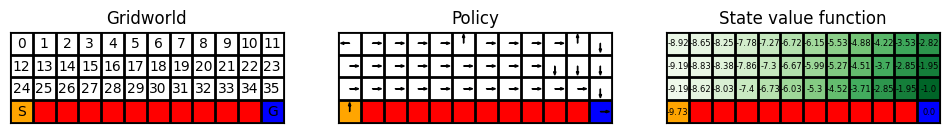

In [6]:
gw = GW.CliffWalking_Example()

Q, policy, rewards = q_learning(gw, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)

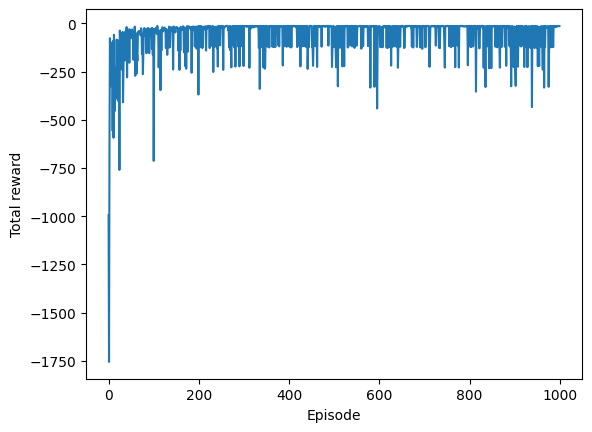

In [7]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.show()